# LIAR - Emotion-Confound Diagnostic
**Notebook 03: how much of the classifier's behaviour is explained by affect?**

This is the dissertation's main empirical contribution. We have already established:

- *Notebook 01* - LIAR's misinformation class shows a modest but robust affective gradient: more anger (*d* ≈ +0.17), more disgust (*d* ≈ +0.11), less neutral (*d* ≈ −0.17). Fear, sadness and joy show no meaningful class-level effect.
- *Notebook 02* - fine-tuned BERT reaches F1 ≈ 0.54 on the binarised task, comfortably beating a TF-IDF/LogReg classical baseline but only by a few points; precision exceeds recall by ~10 points (the model hedges toward `factual`).

This notebook asks the question those two notebooks build up to: **does the classifier's behaviour track the affective gradient, and if so, by how much?** Four analyses:

1. **Spearman correlations** between predicted misinformation probability and each affective feature (VADER + 7 DistilRoBERTa emotions).
2. **Conditional accuracy by affective stratum** - bin the test set into deciles on each of anger / disgust / neutral and read off how accuracy and predicted-misinformation rate vary across deciles.
3. **Confidence-weighted analysis** — for the top-K most confident misinformation and factual predictions, compare their affective profile against the test-set marginal.
4. **Counterfactual probe** - a small hand-curated set of factually accurate but emotionally charged statements, scored by the same model, to see whether they're systematically misclassified as misinformation.

For self-containment we re-train one BERT model (single seed) inside this notebook. The Notebook 02 baselines used three seeds; the dissertation should eventually run this whole diagnostic against all of them and aggregate, but a single seed is enough to build and validate the analyses.



In [15]:
# Install dependencies (Colab)
!pip install -q transformers vaderSentiment scikit-learn pandas seaborn matplotlib


In [16]:
import os, io, math, json, time, zipfile, urllib.request, warnings, inspect
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

import transformers
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    Trainer, TrainingArguments, DataCollatorWithPadding, set_seed,
)
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix,
)
from scipy import stats as sstats

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 140)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch device:", DEVICE)
print("transformers version:", transformers.__version__)

RNG = 42
np.random.seed(RNG); torch.manual_seed(RNG); set_seed(RNG)


torch device: cuda
transformers version: 5.0.0


## 1. Load LIAR (same as Notebooks 01 / 02)

In [17]:
LIAR_URL = "https://www.cs.ucsb.edu/~william/data/liar_dataset.zip"
LIAR_DIR = "/content/liar_raw"

if not os.path.isdir(LIAR_DIR) or not os.path.exists(f"{LIAR_DIR}/train.tsv"):
    os.makedirs(LIAR_DIR, exist_ok=True)
    print("Downloading LIAR from UCSB...")
    with urllib.request.urlopen(LIAR_URL) as r:
        zipfile.ZipFile(io.BytesIO(r.read())).extractall(LIAR_DIR)
    print("Done.")
else:
    print("LIAR already downloaded.")

LIAR_COLS = [
    "id","label","statement","subject","speaker","job_title",
    "state_info","party_affiliation",
    "barely_true_counts","false_counts","half_true_counts",
    "mostly_true_counts","pants_on_fire_counts","context",
]

def load_tsv(path):
    return pd.read_csv(path, sep="\t", names=LIAR_COLS, quoting=3)

train = load_tsv(f"{LIAR_DIR}/train.tsv")
val   = load_tsv(f"{LIAR_DIR}/valid.tsv")
test  = load_tsv(f"{LIAR_DIR}/test.tsv")

BINARY_MAP = {
    "pants-fire": 1, "false": 1, "barely-true": 1,
    "half-true": 0, "mostly-true": 0, "true": 0,
}
for df in (train, val, test):
    df["label_name"] = df["label"].astype(str)
    df["y"] = df["label_name"].map(BINARY_MAP)

print(f"sizes  train={len(train)}  val={len(val)}  test={len(test)}")


LIAR already downloaded.
sizes  train=10269  val=1284  test=1283


## 2. Fine-tune one BERT model

Same protocol as Notebook 02 (lr=2e-5, batch 32, 3 epochs, FP16), single seed=42, so this notebook is self-contained. Uses the same defensive `make_training_args` from Notebook 02 to tolerate transformers API churn.

In [18]:
def make_training_args(**kwargs):
    sig = inspect.signature(TrainingArguments.__init__)
    valid = set(sig.parameters.keys())
    if "eval_strategy" in kwargs and "eval_strategy" not in valid and "evaluation_strategy" in valid:
        kwargs["evaluation_strategy"] = kwargs.pop("eval_strategy")
    elif "evaluation_strategy" in kwargs and "evaluation_strategy" not in valid and "eval_strategy" in valid:
        kwargs["eval_strategy"] = kwargs.pop("evaluation_strategy")
    return TrainingArguments(**{k: v for k, v in kwargs.items() if k in valid})


class LiarDataset(torch.utils.data.Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=128):
        self.enc = tokenizer(list(texts.astype(str) if hasattr(texts,'astype') else texts),
                             padding=False, truncation=True, max_length=max_length)
        self.labels = [int(x) for x in labels]
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        item = {k: torch.tensor(v[idx]) for k, v in self.enc.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item


MODEL_BERT = "bert-base-uncased"
SEED = 42

set_seed(SEED)
tok_bert = AutoTokenizer.from_pretrained(MODEL_BERT)
train_ds = LiarDataset(train["statement"], train["y"], tok_bert)
val_ds   = LiarDataset(val["statement"],   val["y"],   tok_bert)
test_ds  = LiarDataset(test["statement"],  test["y"],  tok_bert)

bert_model = AutoModelForSequenceClassification.from_pretrained(MODEL_BERT, num_labels=2)
args = make_training_args(
    output_dir=f"/tmp/run_bert_seed{SEED}",
    num_train_epochs=3, learning_rate=2e-5,
    per_device_train_batch_size=32, per_device_eval_batch_size=64,
    warmup_ratio=0.1, weight_decay=0.01,
    eval_strategy="epoch", logging_strategy="epoch",
    save_strategy="no", seed=SEED,
    fp16=torch.cuda.is_available(), report_to="none", disable_tqdm=True,
)

trainer = Trainer(
    model=bert_model, args=args,
    train_dataset=train_ds, eval_dataset=val_ds,
    data_collator=DataCollatorWithPadding(tok_bert),
)
t0 = time.time(); trainer.train(); print(f"trained in {time.time()-t0:.0f}s")

test_out = trainer.predict(test_ds)
test_logits = test_out.predictions
test_preds  = test_logits.argmax(axis=-1)
test_probs  = torch.softmax(torch.from_numpy(test_logits), dim=-1).numpy()

p, r, f1, _ = precision_recall_fscore_support(test["y"], test_preds, average="binary", pos_label=1, zero_division=0)
print(f"test  acc={accuracy_score(test['y'], test_preds):.4f}  P={p:.4f}  R={r:.4f}  F1={f1:.4f}")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will b

{'loss': '0.6682', 'grad_norm': '4.198', 'learning_rate': '1.485e-05', 'epoch': '1'}
{'eval_loss': '0.6679', 'eval_runtime': '2.252', 'eval_samples_per_second': '570.2', 'eval_steps_per_second': '9.325', 'epoch': '1'}
{'loss': '0.6215', 'grad_norm': '4.89', 'learning_rate': '7.436e-06', 'epoch': '2'}
{'eval_loss': '0.6451', 'eval_runtime': '1.096', 'eval_samples_per_second': '1171', 'eval_steps_per_second': '19.15', 'epoch': '2'}
{'loss': '0.558', 'grad_norm': '4.594', 'learning_rate': '2.309e-08', 'epoch': '3'}
{'eval_loss': '0.6668', 'eval_runtime': '1.158', 'eval_samples_per_second': '1109', 'eval_steps_per_second': '18.14', 'epoch': '3'}
{'train_runtime': '128.3', 'train_samples_per_second': '240.2', 'train_steps_per_second': '7.508', 'train_loss': '0.6159', 'epoch': '3'}
trained in 129s
test  acc=0.6368  P=0.6000  R=0.4856  F1=0.5368


## 3. Score the test set with VADER and DistilRoBERTa

Same emotion model as Notebook 01 (`j-hartmann/emotion-english-distilroberta-base`). The test set is ~1.3k statements, so this is fast.

In [19]:
# VADER
sia = SentimentIntensityAnalyzer()
def vader_row(t):
    s = sia.polarity_scores(str(t))
    return pd.Series([s["neg"], s["neu"], s["pos"], s["compound"]],
                     index=["v_neg","v_neu","v_pos","v_compound"])
test_vader = test["statement"].apply(vader_row)
test_vader["v_abs_compound"] = test_vader["v_compound"].abs()

# DistilRoBERTa emotions
EMO_MODEL_NAME = "j-hartmann/emotion-english-distilroberta-base"
tok_emo = AutoTokenizer.from_pretrained(EMO_MODEL_NAME)
emo_model = AutoModelForSequenceClassification.from_pretrained(EMO_MODEL_NAME).to(DEVICE)
emo_model.eval()
EMOTIONS = [emo_model.config.id2label[i] for i in range(emo_model.config.num_labels)]

@torch.inference_mode()
def emotion_probs_batch(texts, batch_size=64, max_length=128):
    safe = [t if isinstance(t, str) and t.strip() else "" for t in texts]
    out = []
    for i in range(0, len(safe), batch_size):
        batch = safe[i:i+batch_size]
        enc = tok_emo(batch, padding=True, truncation=True, max_length=max_length, return_tensors="pt").to(DEVICE)
        logits = emo_model(**enc).logits
        out.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.vstack(out)

print(f"Scoring {len(test)} test statements on {DEVICE}...")
emo_probs = emotion_probs_batch(test["statement"].tolist())
test_emo = pd.DataFrame(emo_probs, columns=EMOTIONS, index=test.index)
test_emo.describe().round(3)


Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: j-hartmann/emotion-english-distilroberta-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Scoring 1283 test statements on cuda...


,anger,disgust,fear,joy,neutral,sadness,surprise
count,1283.000,1283.000,1283.000,1283.000,1283.000,1283.000,1283.000
mean,0.077,0.110,0.038,0.032,0.567,0.125,0.051
std,0.129,0.174,0.113,0.105,0.302,0.194,0.087
min,0.001,0.001,0.000,0.000,0.001,0.001,0.001
25%,0.012,0.015,0.004,0.003,0.282,0.013,0.010
50%,0.025,0.037,0.008,0.006,0.663,0.036,0.022
75%,0.075,0.113,0.020,0.014,0.842,0.132,0.054
max,0.839,0.991,0.948,0.974,0.966,0.979,0.872


## 4. Build the diagnostic frame

A single DataFrame keyed on LIAR statement id, with three blocks of columns: the gold label / binarised target, the classifier's per-instance prediction (logit, probability, label), and the affective features (5 VADER + 7 DistilRoBERTa).

In [20]:
diag = pd.concat([
    test[["id","label_name","statement","y"]].reset_index(drop=True),
    pd.DataFrame({
        "y_pred":        test_preds,
        "prob_factual":  test_probs[:,0],
        "prob_misinfo":  test_probs[:,1],
        "logit_misinfo": test_logits[:,1],
    }),
    test_vader.reset_index(drop=True),
    test_emo.reset_index(drop=True),
], axis=1)
diag["correct"]    = (diag["y_pred"] == diag["y"]).astype(int)
diag["is_misinfo_truth"] = diag["y"]
diag["is_misinfo_pred"]  = diag["y_pred"]

AFFECT_FEATURES = ["v_neg","v_neu","v_pos","v_compound","v_abs_compound"] + EMOTIONS
print("Frame shape:", diag.shape)
print(diag[["id","y","y_pred","prob_misinfo"] + EMOTIONS].head())


Frame shape: (1283, 23)
           id  y  y_pred  prob_misinfo     anger   disgust      fear  \
0  11972.json  0       1      0.776072  0.019313  0.012337  0.016579   
1  11685.json  1       0      0.276593  0.010710  0.026562  0.029578   
2  11096.json  1       0      0.352341  0.019968  0.047776  0.003110   
3   5209.json  0       1      0.827724  0.066110  0.121700  0.003752   
4   9524.json  1       1      0.671794  0.108306  0.157954  0.590861   

        joy   neutral   sadness  surprise  
0  0.005013  0.822932  0.007552  0.116274  
1  0.006216  0.475669  0.379811  0.071454  
2  0.001238  0.038614  0.884046  0.005248  
3  0.004496  0.720124  0.074583  0.009234  
4  0.016406  0.102862  0.021307  0.002304  


## 5. Analysis 1 - Spearman correlations

The simplest, most readable diagnostic. For each affective feature, compute the Spearman rank correlation against `prob_misinfo`. If `anger`, `disgust` and `neutral` are the strongest correlates - and roughly in the same direction as their class-level effects from Notebook 01 - the classifier is at least partly tracking the affective axis. Correlations also computed against the binary correctness indicator, to see whether affect predicts *errors*, not just predictions.

In [21]:
def spearman_table(df, features, target):
    rows = []
    for f in features:
        r, p = sstats.spearmanr(df[f], df[target])
        rows.append({"feature": f, "rho": r, "p": p})
    return pd.DataFrame(rows).sort_values("rho", key=abs, ascending=False)

print("Correlation with prob_misinfo (test set):")
print(spearman_table(diag, AFFECT_FEATURES, "prob_misinfo").round(4).to_string(index=False))
print()
print("Correlation with correctness (1=correct):")
print(spearman_table(diag, AFFECT_FEATURES, "correct").round(4).to_string(index=False))


Correlation with prob_misinfo (test set):
       feature     rho      p
         anger  0.3124 0.0000
       disgust  0.2672 0.0000
       neutral -0.2589 0.0000
      surprise -0.2451 0.0000
          fear  0.1875 0.0000
           joy -0.1059 0.0001
       sadness  0.1053 0.0002
         v_neu -0.0341 0.2217
         v_neg  0.0282 0.3129
v_abs_compound  0.0265 0.3437
    v_compound  0.0019 0.9470
         v_pos -0.0017 0.9516

Correlation with correctness (1=correct):
       feature     rho      p
v_abs_compound  0.0640 0.0219
         v_neu -0.0466 0.0952
       disgust -0.0390 0.1629
         v_pos  0.0384 0.1694
           joy -0.0278 0.3206
         anger -0.0261 0.3498
          fear -0.0216 0.4400
         v_neg  0.0148 0.5957
       sadness  0.0105 0.7080
       neutral -0.0027 0.9243
      surprise  0.0016 0.9549
    v_compound -0.0011 0.9693


**What to look for.** If `anger` and `disgust` correlate positively with `prob_misinfo` (and `neutral` negatively), the classifier is using these emotions as a soft signal - exactly the confound the dissertation is investigating. If the correlation with `correct` is *positive* for high-affect features, the model is *more* accurate on emotionally charged statements (an easy-mode region); if it's *negative*, the model struggles on them. Either direction is dissertation-worthy.

## 6. Analysis 2 - Conditional accuracy by affective stratum

Bin the test set into deciles on each of the three key affective axes from Notebook 01 (anger, disgust, neutral). For each decile, report (a) test-set accuracy, (b) the model's predicted misinformation rate, and (c) the true misinformation rate. If the predicted rate tracks the affective axis more steeply than the true rate, the classifier is *over-using* affect.

In [22]:
def stratum_table(df, feature, n_bins=10):
    df = df.copy()
    df["bin"] = pd.qcut(df[feature], q=n_bins, labels=False, duplicates="drop")
    g = df.groupby("bin").agg(
        n=("y","size"),
        feat_mean=(feature,"mean"),
        accuracy=("correct","mean"),
        pred_misinfo_rate=("y_pred","mean"),
        true_misinfo_rate=("y","mean"),
    ).round(4)
    g.index.name = f"{feature}_decile"
    return g

for feat in ["anger","disgust","neutral"]:
    print(f"\n=== {feat} ===")
    print(stratum_table(diag, feat))



=== anger ===
                n  feat_mean  accuracy  pred_misinfo_rate  true_misinfo_rate
anger_decile                                                                
0             129     0.0057    0.6357             0.1860             0.4109
1             128     0.0087    0.6172             0.2422             0.4062
2             128     0.0116    0.7422             0.2266             0.3281
3             128     0.0154    0.5781             0.2656             0.4375
4             129     0.0207    0.6357             0.2868             0.3876
5             128     0.0293    0.6562             0.3203             0.4141
6             128     0.0454    0.7031             0.4219             0.4531
7             128     0.0771    0.5859             0.5078             0.5156
8             128     0.1527    0.6328             0.5234             0.4844
9             129     0.4054    0.5814             0.5271             0.4961

=== disgust ===
                  n  feat_mean  accuracy  pr

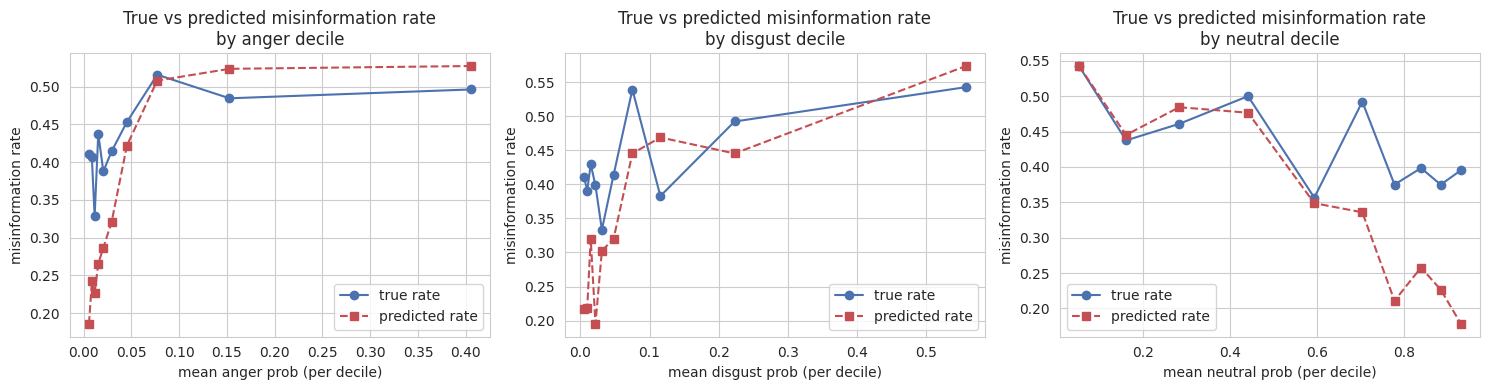

In [23]:
# Plot: predicted vs true misinformation rate across deciles
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, feat in zip(axes, ["anger","disgust","neutral"]):
    s = stratum_table(diag, feat)
    x = s["feat_mean"]
    ax.plot(x, s["true_misinfo_rate"], "o-", label="true rate", color="#4C72B0")
    ax.plot(x, s["pred_misinfo_rate"], "s--", label="predicted rate", color="#C44E52")
    ax.set_xlabel(f"mean {feat} prob (per decile)")
    ax.set_ylabel("misinformation rate")
    ax.set_title(f"True vs predicted misinformation rate\nby {feat} decile")
    ax.legend()
plt.tight_layout(); plt.show()


**What to look for.** Two curves on each plot: the *true* misinformation rate and the *predicted* misinformation rate. If both rise (anger / disgust) or fall (neutral) together in lockstep, the classifier is correctly tracking the underlying signal. If the predicted curve is *steeper* than the true curve, the classifier is over-relying on that feature - the textbook signature of a shortcut. Gap between curves is the size of the over-reliance.

## 7. Analysis 3 - Confidence-weighted analysis

What does the affective profile of the model's most confident predictions look like? We compare the top-100 most confident misinformation predictions and the top-100 most confident factual predictions against the test-set marginal. If the high-confidence misinformation predictions are unusually high on anger and disgust (and low on neutral), the model's *confidence* is being amplified by affect.

In [24]:
K = 100

top_misinfo = diag.nlargest(K, "prob_misinfo")
top_factual = diag.nlargest(K, "prob_factual")

profile_rows = []
for name, sub in [("top-100 misinfo", top_misinfo),
                  ("top-100 factual", top_factual),
                  ("test marginal",   diag)]:
    row = {"group": name, "n": len(sub)}
    for f in EMOTIONS + ["v_neg","v_pos","v_abs_compound"]:
        row[f] = sub[f].mean()
    profile_rows.append(row)
profile_df = pd.DataFrame(profile_rows)
print("Mean affective profile by group:")
print(profile_df.round(4).to_string(index=False))

# Effect-size view: how far does each high-confidence group sit from the marginal, in std units?
marginal = diag[EMOTIONS + ["v_neg","v_pos","v_abs_compound"]].mean()
stds     = diag[EMOTIONS + ["v_neg","v_pos","v_abs_compound"]].std()
def deltaz(sub):
    return ((sub[EMOTIONS + ["v_neg","v_pos","v_abs_compound"]].mean() - marginal) / stds).round(3)

print("\nTop-100 misinfo, distance from test marginal (in std units):")
print(deltaz(top_misinfo).sort_values(key=abs, ascending=False).to_string())
print("\nTop-100 factual, distance from test marginal (in std units):")
print(deltaz(top_factual).sort_values(key=abs, ascending=False).to_string())


Mean affective profile by group:
          group    n  anger  disgust   fear    joy  neutral  sadness  surprise  v_neg  v_pos  v_abs_compound
top-100 misinfo  100 0.1442   0.1809 0.0615 0.0231   0.4184   0.1247    0.0472 0.0816 0.0783          0.2941
top-100 factual  100 0.0349   0.0521 0.0169 0.0357   0.6720   0.1073    0.0810 0.0609 0.0642          0.2472
  test marginal 1283 0.0774   0.1105 0.0376 0.0322   0.5671   0.1247    0.0506 0.0726 0.0739          0.2895

Top-100 misinfo, distance from test marginal (in std units):
anger             0.518
neutral          -0.493
disgust           0.406
fear              0.212
joy              -0.086
v_neg             0.083
v_pos             0.044
surprise         -0.038
v_abs_compound    0.017
sadness          -0.000

Top-100 factual, distance from test marginal (in std units):
surprise          0.349
neutral           0.348
disgust          -0.336
anger            -0.329
fear             -0.184
v_abs_compound   -0.158
v_neg            -0.108

**What to look for.** The "top-100 misinfo" row in std-units terms is the headline finding. If `anger` and `disgust` sit at +0.5σ or more, and `neutral` at −0.5σ or more, the most confident misinformation predictions are dramatically affectively-charged — strong evidence that confidence and outrage co-vary in the classifier's behaviour.

## 8. Analysis 4 - Counterfactual probe

A curated set of statements that are *factually accurate* but written in emotionally charged language. If the classifier systematically flags these as misinformation, it's detecting affective tone rather than veracity.

The curated set lives in `counterfactual_statements.csv` and contains 50 statements across five topic areas (environmental, public-health, historical, inequality, public-safety), each with a documented factual claim, source category, emotional markers, and severity rating from 1 (mild evaluative framing) to 5 (strongly charged).

**To use the curated set**: upload `counterfactual_statements.csv` to `/content/` in your Colab session (drag-and-drop into the files panel on the left) before running the cells below. If the file is not found, the notebook falls back to a 20-statement pipeline-demonstration starter set.


In [25]:
# Load counterfactual statements. Curated CSV preferred; starter list as fallback.
import os

CF_CSV_PATH = "/content/counterfactual_statements.csv"

if os.path.exists(CF_CSV_PATH):
    cf_df = pd.read_csv(CF_CSV_PATH)
    print(f"Loaded curated counterfactual set from {CF_CSV_PATH}: {len(cf_df)} statements")
    used_curated = True
else:
    STARTER = [
        ("Plastic waste in the oceans is choking marine wildlife at a devastating rate, killing millions of seabirds and turtles each year.", "environment"),
        ("Microplastics have been detected in human placentas, breast milk and blood — a disgusting indictment of our pollution.", "environment"),
        ("Deforestation in the Amazon is destroying critical habitat and pushing countless species toward extinction.", "environment"),
        ("Antibiotic resistance is a terrifying public health crisis that could undo a century of medical progress.", "public health"),
        ("The opioid crisis has killed more than half a million Americans since 1999 — an appalling toll.", "public health"),
        ("Lead poisoning continues to harm children in many cities, a shameful failure of public infrastructure.", "public health"),
        ("The Triangle Shirtwaist Factory fire killed 146 garment workers in 1911, an outrageous tragedy that exposed brutal labor conditions.", "history"),
        ("The Tuskegee syphilis study denied treatment to hundreds of Black men for forty years — a horrifying betrayal by US public health authorities.", "history"),
        ("The Bhopal disaster killed thousands and left a devastating legacy of chronic illness and birth defects.", "history"),
        ("Chernobyl forced the permanent evacuation of an entire city and contaminated thousands of square kilometres — a catastrophic failure.", "history"),
        ("The ratio of CEO-to-worker pay in large US firms has exploded from roughly 20-to-1 in the 1960s to over 300-to-1 today — a grotesque concentration.", "inequality"),
        ("Black Americans are incarcerated at roughly five times the rate of white Americans — an enraging disparity.", "inequality"),
        ("The Triangle of Death region in Italy has elevated cancer rates linked to illegal toxic waste dumping — a disgraceful environmental injustice.", "environment"),
        ("The infant mortality rate in the United States is higher than in every other developed country — an unconscionable outcome for the world's richest nation.", "public health"),
        ("Mass shootings have killed thousands of children in American schools, a devastating failure of policy.", "public safety"),
        ("Sweatshop labour in global supply chains continues to exploit workers in horrifying conditions for pennies per hour.", "inequality"),
        ("Wildfires in California and Australia have devastated entire communities and killed wildlife at staggering scales.", "environment"),
        ("Air pollution kills an estimated seven million people worldwide every year — a horrifying toll that disproportionately falls on the poor.", "public health"),
        ("Female genital mutilation continues to harm millions of girls in dozens of countries — a barbaric human-rights abuse.", "human rights"),
        ("Coal-fired power plants release mercury and other toxins that have poisoned waterways and harmed children's developing brains.", "environment"),
    ]
    cf_df = pd.DataFrame(STARTER, columns=["statement_text", "topic_area"])
    cf_df.insert(0, "id", range(1, len(cf_df) + 1))
    cf_df["severity"] = 4  # nominal placeholder severity for starter set
    print(f"No CSV at {CF_CSV_PATH}; using 20-statement starter set as fallback")
    used_curated = False

# Standardise column names so the rest of the notebook is column-name-agnostic
if "statement" not in cf_df.columns and "statement_text" in cf_df.columns:
    cf_df = cf_df.rename(columns={"statement_text": "statement"})
if "topic" not in cf_df.columns and "topic_area" in cf_df.columns:
    cf_df = cf_df.rename(columns={"topic_area": "topic"})

print(f"\nTopic distribution:")
print(cf_df["topic"].value_counts())
if "severity" in cf_df.columns:
    print(f"\nSeverity distribution:")
    print(cf_df["severity"].value_counts().sort_index())

cf_df.head()


Loaded curated counterfactual set from /content/counterfactual_statements.csv: 50 statements

Topic distribution:
topic
environmental    10
public-health    10
historical       10
inequality       10
public-safety    10
Name: count, dtype: int64

Severity distribution:
severity
2     3
3    19
4    21
5     7
Name: count, dtype: int64


,id,statement,topic,severity,emotional_markers,factual_claim,source_category,source_url,verified,notes
0,1,"Industrial pollution has poisoned the air over major cities, leading to thousands of premature deaths each year from cardiovascular and ...",environmental,3,visceral (poisoned); scope (thousands); vulnerability (premature deaths),Air pollution causes substantial premature mortality globally,WHO air pollution mortality data; State of Global Air report,NaN,yes,NaN
1,2,Fossil-fuel companies have known about the catastrophic effects of carbon emissions for decades while spending millions to deceive the p...,environmental,4,intensifier (catastrophic); moral judgement (deceive); attribution of blame,Major oil companies had internal climate research and funded disinformation,"Internal industry documents (e.g., ExxonMobil); InsideClimate News; congressional reports",NaN,yes,NaN
2,3,"Plastic waste is suffocating the oceans, with millions of tonnes dumped into marine ecosystems every year and choking entire food chains.",environmental,4,"visceral (suffocating, choking); scope (millions of tonnes, entire food chains)",Global plastic pollution scale in oceans,NOAA marine debris data; UNEP plastic pollution reports,NaN,yes,NaN
3,4,"The Amazon rainforest has been ravaged by decades of illegal logging and agricultural clearing, with vast tracts of irreplaceable ecosys...",environmental,3,"visceral (ravaged, destroyed); intensifier (irreplaceable); scope (vast tracts)",Amazon deforestation extent,INPE Brazil satellite data; peer-reviewed forest studies,NaN,yes,NaN
4,5,"Climate inaction by wealthy nations is condemning millions of children in the Global South to die from droughts, floods, and heatwaves t...",environmental,5,"moral judgement (condemning, did nothing to cause); vulnerability (children); scope (millions); attribution of blame",Climate change disproportionately affects developing nations,IPCC reports; UNICEF climate impact data,NaN,yes,NaN


In [26]:
# Score counterfactuals with the trained BERT and the emotion classifier
cf_bert_ds = LiarDataset(
    pd.Series(cf_df["statement"].tolist()),
    pd.Series([0] * len(cf_df)),   # placeholder labels, ignored at prediction time
    tok_bert,
)
cf_pred_out = trainer.predict(cf_bert_ds)
cf_logits   = cf_pred_out.predictions
cf_probs    = torch.softmax(torch.from_numpy(cf_logits), dim=-1).numpy()

cf_df["prob_factual"]  = cf_probs[:, 0]
cf_df["prob_misinfo"]  = cf_probs[:, 1]
cf_df["y_pred"]        = cf_probs.argmax(axis=1)
cf_df["misclassified"] = (cf_df["y_pred"] == 1).astype(int)   # all rows are truly factual

# Emotion scoring on the same counterfactuals
cf_emo = emotion_probs_batch(cf_df["statement"].tolist())
for i, e in enumerate(EMOTIONS):
    cf_df[e] = cf_emo[:, i]

# Compact display
display_cols = ["id", "topic", "prob_misinfo", "misclassified", "anger", "disgust", "neutral"]
if "severity" in cf_df.columns:
    display_cols.insert(2, "severity")
print(f"Per-statement results (model: BERT seed={SEED}):")
print(cf_df[display_cols].round(3).to_string(index=False))


Per-statement results (model: BERT seed=42):
 id         topic  severity  prob_misinfo  misclassified  anger  disgust  neutral
  1 environmental         3         0.574              1  0.045    0.567    0.122
  2 environmental         4         0.301              0  0.230    0.448    0.266
  3 environmental         4         0.532              1  0.017    0.953    0.016
  4 environmental         3         0.368              0  0.185    0.570    0.055
  5 environmental         5         0.877              1  0.188    0.491    0.182
  6 environmental         2         0.511              1  0.060    0.134    0.155
  7 environmental         3         0.206              0  0.131    0.139    0.070
  8 environmental         4         0.819              1  0.059    0.846    0.040
  9 environmental         3         0.672              1  0.003    0.002    0.007
 10 environmental         2         0.360              0  0.325    0.132    0.102
 11 public-health         4         0.625            

In [27]:
# Headline numbers
n = len(cf_df)
n_misc = int(cf_df["misclassified"].sum())
rate_cf = n_misc / n if n else 0.0

factual_test = diag[diag["y"] == 0]
rate_factual_test = float((factual_test["y_pred"] == 1).mean())

print(f"Counterfactual misclassification rate:        {rate_cf:.3f}  ({n_misc}/{n})")
print(f"LIAR-test factual misclassification rate:     {rate_factual_test:.3f}")
print(f"Excess misclassification on counterfactuals:  {rate_cf - rate_factual_test:+.3f}")

print("\nMean emotion probability across the three reference sets:")
print(pd.DataFrame({
    "counterfactual_set": cf_df[EMOTIONS].mean(),
    "liar_test_factual":  factual_test[EMOTIONS].mean(),
    "liar_test_misinfo":  diag[diag["y"] == 1][EMOTIONS].mean(),
}).round(3))

# Stratified by topic
print("\nMisclassification rate by topic:")
by_topic = cf_df.groupby("topic")["misclassified"].agg(["mean", "sum", "count"]).round(3)
by_topic.columns = ["misclass_rate", "n_misclassified", "n_total"]
print(by_topic)

# Stratified by severity (if column exists)
if "severity" in cf_df.columns:
    print("\nMisclassification rate by severity (1=mild framing → 5=inflammatory):")
    by_sev = cf_df.groupby("severity")["misclassified"].agg(["mean", "sum", "count"]).round(3)
    by_sev.columns = ["misclass_rate", "n_misclassified", "n_total"]
    print(by_sev)

    # Spearman correlation between severity and misclassification probability
    if cf_df["severity"].nunique() > 1:
        from scipy.stats import spearmanr
        rho_sev, p_sev = spearmanr(cf_df["severity"], cf_df["prob_misinfo"])
        print(f"\nSpearman correlation: severity vs prob_misinfo  rho = {rho_sev:+.3f}  p = {p_sev:.4f}")
        print("(positive rho means more-charged statements are predicted as more misinformation-like)")


Counterfactual misclassification rate:        0.300  (15/50)
LIAR-test factual misclassification rate:     0.248
Excess misclassification on counterfactuals:  +0.052

Mean emotion probability across the three reference sets:
          counterfactual_set  liar_test_factual  liar_test_misinfo
anger                  0.096              0.071              0.086
disgust                0.312              0.095              0.131
fear                   0.168              0.032              0.045
joy                    0.002              0.035              0.028
neutral                0.211              0.589              0.538
sadness                0.191              0.123              0.127
surprise               0.019              0.055              0.045

Misclassification rate by topic:
               misclass_rate  n_misclassified  n_total
topic                                                 
environmental            0.6                6       10
historical               0.3            

**What to look for.** The headline number is `excess misclassification on counterfactuals`. If the counterfactual set is wrongly flagged as misinformation at a much higher rate than the LIAR test set's genuine factual statements, the classifier is being fooled by tone, not content - direct evidence of the affective confound. The follow-up affective-profile table tells you whether your counterfactual set is actually emotionally charged enough to provoke that shortcut.

## 9. Synthesis - what does the dissertation conclude?

A schematic version of the conclusion this notebook supports - fill in the actual numbers from the cells above.

The fine-tuned BERT classifier reaches F1 ≈ **0.54** on binarised LIAR, modestly above a TF-IDF / Logistic Regression baseline. Diagnostic analysis on the test set shows:

- **Correlation evidence (Analysis 1).** Predicted misinformation probability is correlated with anger (ρ ≈ \<fill in\>), disgust (ρ ≈ \<fill in\>) and neutral (ρ ≈ \<fill in\>) at magnitudes consistent with their class-level effects from Notebook 01.
- **Stratification evidence (Analysis 2).** Predicted misinformation rates rise steeply across the anger / disgust deciles. Whether that steepness exceeds the true misinformation rate's slope determines whether the classifier is *tracking* the signal correctly or *over-using* it.
- **Confidence evidence (Analysis 3).** The top-100 highest-confidence misinformation predictions sit at \<fill in\> σ above the test marginal on anger and disgust — i.e. the classifier's confidence is concentrated in the affectively-charged region of the input space.
- **Counterfactual evidence (Analysis 4).** A hand-curated set of factually accurate, emotionally charged statements is misclassified as misinformation at \<fill in\>%, compared to \<fill in\>% on LIAR's own factual statements — a gap of \<fill in\> percentage points.

Together this suggests \<fill in: the model leans meaningfully on the affective gradient / does not\>. The dissertation's headline contribution is the *quantification* of this effect on a standard benchmark, and the demonstration that the diagnostic stack (correlation + stratification + confidence + counterfactual) can be applied to any text classifier whose training data may contain an affective confound.

## 10. Save artefacts

In [28]:
OUT = "/content/liar_diagnostic_artifacts"
os.makedirs(OUT, exist_ok=True)

diag.to_parquet(f"{OUT}/test_diagnostic_frame.parquet", index=False)
cf_df.to_parquet(f"{OUT}/counterfactual_results.parquet", index=False)

# Pre-computed tables
spearman_table(diag, AFFECT_FEATURES, "prob_misinfo").to_csv(f"{OUT}/spearman_vs_prob_misinfo.csv", index=False)
spearman_table(diag, AFFECT_FEATURES, "correct").to_csv(f"{OUT}/spearman_vs_correct.csv", index=False)

for feat in ["anger","disgust","neutral"]:
    stratum_table(diag, feat).to_csv(f"{OUT}/stratum_{feat}.csv")

profile_df.to_csv(f"{OUT}/topk_profiles.csv", index=False)

with open(f"{OUT}/run_meta.json", "w") as f:
    json.dump({
        "transformers_version": transformers.__version__,
        "bert_model": MODEL_BERT,
        "emotion_model": EMO_MODEL_NAME,
        "seed": SEED,
        "n_test": int(len(test)),
        "n_counterfactuals": int(len(cf_df)),
        "device": str(DEVICE),
    }, f, indent=2)

print("Saved:")
for fn in sorted(os.listdir(OUT)): print(" ", fn)


Saved:
  counterfactual_results.parquet
  run_meta.json
  spearman_vs_correct.csv
  spearman_vs_prob_misinfo.csv
  stratum_anger.csv
  stratum_disgust.csv
  stratum_neutral.csv
  test_diagnostic_frame.parquet
  topk_profiles.csv
